#Маскалева Полина ЗФИбд-01-24 Лабораторная работа 7

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef,
    average_precision_score, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings('ignore')
np.random.seed(2026)
tf.random.set_seed(2026)

## 2. Загрузка данных

In [71]:
df1 = pd.read_csv('PS_2017_1.csv')
df2 = pd.read_csv('PS_2017_2.csv')
df  = pd.concat([df1, df2], ignore_index=True)
del df1, df2  # освобождаем память — это важно, файлы по ~250 МБ каждый

In [72]:
# Чистка: удаляем строки с пропусками в критичных колонках
critical_cols = ['isFraud', 'type', 'amount', 'step',
                 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest']
before = len(df)
df = df.dropna(subset=critical_cols).reset_index(drop=True)
print(f"Удалено строк с NaN: {before - len(df)}")

# Принудительно приводим типы (на случай, если загрузились как object)
df['isFraud'] = df['isFraud'].astype(int)
df['isFlaggedFraud'] = df['isFlaggedFraud'].fillna(0).astype(int)
df['step'] = df['step'].astype(int)
for c in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    df[c] = df[c].astype(float)

print(f"После очистки: {df.shape}, фрод: {df['isFraud'].sum()}")

Удалено строк с NaN: 2
После очистки: (2379586, 11), фрод: 2424


In [73]:
# Распределение классов
print("Распределение isFraud:")
print(df['isFraud'].value_counts())
print(f"Доля мошеннических транзакций: {df['isFraud'].mean()*100:.4f}%")
print(f"Распределение по типу транзакций:")
print(df['type'].value_counts())
print(f"Мошенничество по типам транзакций:")
print(df.groupby('type')['isFraud'].agg(['sum', 'mean']).rename(
    columns={'sum': 'фрод', 'mean': 'доля фрода'}))
print(f"Пропуски в данных: {df.isnull().sum().sum()}")

Распределение isFraud:
isFraud
0    2377162
1       2424
Name: count, dtype: int64
Доля мошеннических транзакций: 0.1019%
Распределение по типу транзакций:
type
CASH_OUT    837406
PAYMENT     812797
CASH_IN     516803
TRANSFER    197264
DEBIT        15316
Name: count, dtype: int64
Мошенничество по типам транзакций:
          фрод  доля фрода
type                      
CASH_IN      0    0.000000
CASH_OUT  1219    0.001456
DEBIT        0    0.000000
PAYMENT      0    0.000000
TRANSFER  1205    0.006109
Пропуски в данных: 0


**Наблюдения по EDA:**- Сильный дисбаланс классов: только ~0.13% транзакций — мошеннические.- Мошенничество встречается **только в транзакциях типа `TRANSFER` и `CASH_OUT`** (это особенность симуляции PaySim — мошенник переводит деньги на подставной счёт и затем их обналичивает).- Пропусков нет.

## 3. Препроцессинг и конструирование признаков
Идентификаторы клиентов nameOrig и nameDest напрямую неинформативны (миллионы уникальных значений). Зато из балансов и сумм можно извлечь поведенческие признаки.
**Вывод:** в типичной мошеннической транзакции счёт жертвы полностью опустошается — `amount == oldbalanceOrg`. Эту бинарную особенность важно явно выделить как признак: на ней многие методы обнаружения аномалий начинают работать значительно лучше.Также применяем log1p к балансам и суммам — они имеют сильно скошенное распределение, и логарифмирование делает их более «нормальными».

In [74]:
# Признаки на основе балансов и ошибок реконструкции баланса
df['errorOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

#  Временной признак — час суток
df['hourOfDay'] = df['step'] % 24

# Логарифмические признаки
df['amount_log']  = np.log1p(df['amount'])
df['oldOrg_log']  = np.log1p(df['oldbalanceOrg'])
df['newOrg_log']  = np.log1p(df['newbalanceOrig'])
df['oldDest_log'] = np.log1p(df['oldbalanceDest'])
df['newDest_log'] = np.log1p(df['newbalanceDest'])

#  Бизнес-индикатор: счёт опустошён (паттерн мошенничества PaySim)
df['amount_eq_oldOrg'] = ((df['amount'] == df['oldbalanceOrg']) & (df['oldbalanceOrg'] > 0)).astype(int)
df['origDrained']     = ((df['newbalanceOrig'] < 1) & (df['oldbalanceOrg'] > 0)).astype(int)

# Тип транзакции (one-hot)
df['isTransfer'] = (df['type'] == 'TRANSFER').astype(int)
df['isCashOut']  = (df['type'] == 'CASH_OUT').astype(int)
df['isRisk']     = (df['isTransfer'] | df['isCashOut']).astype(int)

feature_cols = [
    'amount_log', 'oldOrg_log', 'newOrg_log', 'oldDest_log', 'newDest_log',
    'errorOrig', 'errorDest', 'hourOfDay',
    'amount_eq_oldOrg', 'origDrained',
    'isTransfer', 'isCashOut', 'isRisk'
]
print(f"Сконструировано признаков: {len(feature_cols)}")
print(feature_cols)

Сконструировано признаков: 13
['amount_log', 'oldOrg_log', 'newOrg_log', 'oldDest_log', 'newDest_log', 'errorOrig', 'errorDest', 'hourOfDay', 'amount_eq_oldOrg', 'origDrained', 'isTransfer', 'isCashOut', 'isRisk']


## 4. Разбиение на обучающую и тестовую выборки
Разбиваем данные в соотношении 70/30. Используем стратификацию по `isFraud`, чтобы доля мошеннических транзакций была одинакова в train и test.

In [75]:
X = df[feature_cols].values.astype(np.float32)
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2026, stratify=y
)

print(f"Train: {X_train.shape}, мошеннических: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test : {X_test.shape}, мошеннических: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Train: (1665710, 13), мошеннических: 1697 (0.1019%)
Test : (713876, 13), мошеннических: 727 (0.1018%)


In [76]:
# Масштабирование признаков (StandardScaler фитим только на train, чтобы избежать утечки данных)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

print("Масштабирование выполнено.")
print(f"Train: mean={X_train_sc.mean():.3f}, std={X_train_sc.std():.3f}")

Масштабирование выполнено.
Train: mean=-0.000, std=1.000


---## 5. Вспомогательная функция оценки качестваДля каждой модели нужно вывести:- матрицу ошибок (TN, FP, FN, TP),- MCC (коэффициент корреляции Мэтьюса),- PR-AUC (площадь под кривой Precision-Recall).Также реализуем подбор оптимального порога: модели аномалий выдают **скоры аномальности**, и выбор порога принципиально влияет на MCC. Будем перебирать пороги по перцентилям и выбирать тот, который максимизирует MCC.

In [77]:
def find_best_threshold(scores, y_true, percentiles=None):
    """Перебор порогов по перцентилям. Возвращает (best_threshold, best_mcc)."""
    if percentiles is None:
        percentiles = np.concatenate([
            np.linspace(98.0, 99.5, 16),
            np.linspace(99.5, 99.95, 30),
        ])
    best_thr, best_mcc = None, -2.0
    for p in percentiles:
        thr = np.percentile(scores, p)
        y_pred = (scores > thr).astype(int)
        if y_pred.sum() == 0:
            continue
        mcc = matthews_corrcoef(y_true, y_pred)
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return best_thr, best_mcc


def evaluate_model(name, scores, y_true):
    """Полная оценка модели. Возвращает словарь с метриками и PR-кривой."""
    # 1. Подбор оптимального порога по MCC
    best_thr, _ = find_best_threshold(scores, y_true)
    y_pred = (scores > best_thr).astype(int)

    # 2. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 3. MCC
    mcc = matthews_corrcoef(y_true, y_pred)

    # 4. PR-AUC
    pr_auc = average_precision_score(y_true, scores)

    # 5. PR-кривая
    precision, recall, _ = precision_recall_curve(y_true, scores)

    # 6. Вывод результатов
    print(f"Модель: {name}")

    print(f"Оптимальный порог:  {best_thr:.6f}")
    print()
    print("Матрица ошибок:")
    print(f"  TN (норма верно)         = {tn:>8}")
    print(f"  FP (ложная тревога)      = {fp:>8}")
    print(f"  FN (фрод пропущен)       = {fn:>8}")
    print(f"  TP (фрод обнаружен)      = {tp:>8}")
    print()
    print(f"  MCC    (Matthews coef)   = {mcc:.4f}")
    print(f"  PR-AUC (Precision-Recall AUC) = {pr_auc:.4f}")

    return {
        'name': name, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'mcc': mcc, 'pr_auc': pr_auc,
        'precision': precision, 'recall': recall,
        'scores': scores, 'y_pred': y_pred, 'threshold': best_thr
    }

# 6. Isolation Forest
**Идея метода:** аномалии «изолируются» в случайных деревьях за меньшее число разбиений, чем нормальные точки.**Гиперпараметры:**- 200 деревьев,- `max_samples=8192` — большой подсэмпл для каждого дерева; критично для этого датасета, чтобы дерево «увидело» редкий мошеннический паттерн (`amount_eq_oldOrg=1`),- `contamination=0.0013` — соответствует реальной доле фрода ~0.13%,- `random_state=2026` — для воспроизводимости.

In [78]:
print("Обучение Isolation Forest")
t0 = time.time()
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples=8192,
    contamination=0.0013,
    random_state=2026,
    n_jobs=-1
)
iso_forest.fit(X_train_sc)
print(f"Обучение завершено за {time.time()-t0:.1f} сек")

# Скоры аномальности (чем больше, тем аномальнее)
scores_if = -iso_forest.score_samples(X_test_sc)
print(f"Скоры на тесте получены, форма: {scores_if.shape}")

Обучение Isolation Forest
Обучение завершено за 41.7 сек
Скоры на тесте получены, форма: (713876,)


In [79]:
result_if = evaluate_model("Isolation Forest", scores_if, y_test)

Модель: Isolation Forest
Оптимальный порог:  0.667606

Матрица ошибок:
  TN (норма верно)         =   712641
  FP (ложная тревога)      =      508
  FN (фрод пропущен)       =      213
  TP (фрод обнаружен)      =      514

  MCC    (Matthews coef)   = 0.5958
  PR-AUC (Precision-Recall AUC) = 0.5861


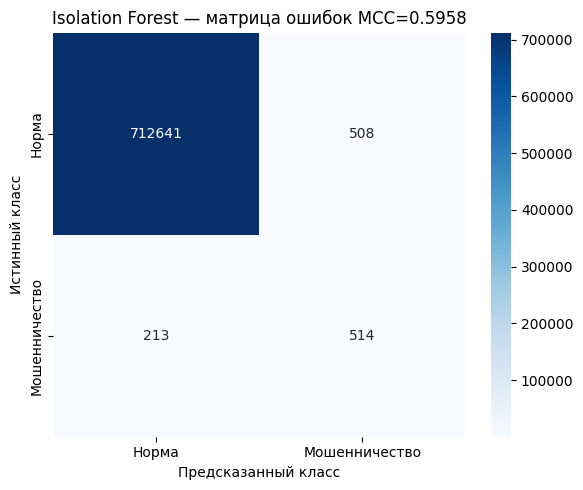

In [80]:
# Визуализация матрицы ошибок
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
cm_if = confusion_matrix(y_test, result_if['y_pred'])
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Норма', 'Мошенничество'],
            yticklabels=['Норма', 'Мошенничество'], ax=ax)
ax.set_title(f'Isolation Forest — матрица ошибок MCC={result_if["mcc"]:.4f}')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 7. Local Outlier Factor (LOF)
**Идея метода:** аномалии лежат в областях с существенно меньшей локальной плотностью точек, чем их соседи.
**Особенность:** LOF вычислительно тяжёлый (O(n^2) расстояний). На полном `train` (4.45 млн строк) применять напрямую невозможно — обучаем на стратифицированной подвыборке, а в режиме `novelty=True` применяем модель к тестовой выборке.
**Гиперпараметры:**- `n_neighbors=20` — стандартное значение для оценки локальной плотности,- `contamination=0.0013` — ожидаемая доля аномалий,- `novelty=True` — позволяет применять модель к новым данным.

In [81]:
# Подвыборка для обучения LOF (только нормальные транзакции — semi-supervised)
N_LOF_TRAIN = 50000  # размер подвыборки
rng = np.random.default_rng(2026)
normal_idx = np.where(y_train == 0)[0]
sub_idx = rng.choice(normal_idx, size=N_LOF_TRAIN, replace=False)
X_train_lof = X_train_sc[sub_idx]
print(f"Обучающая подвыборка для LOF: {X_train_lof.shape}")

print("Обучение LOF")
t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0013,
    novelty=True,
    n_jobs=-1
)
lof.fit(X_train_lof)
print(f"Обучение завершено за {time.time()-t0:.1f} сек")

Обучающая подвыборка для LOF: (50000, 13)
Обучение LOF
Обучение завершено за 7.6 сек


In [82]:
# Скоринг тестовой выборки порциями (чтобы избежать переполнения памяти)
print("Скоринг тестовых данных")
t0 = time.time()
chunk_size = 50000
scores_lof = np.zeros(len(X_test_sc), dtype=np.float32)
for i in range(0, len(X_test_sc), chunk_size):
    j = min(i + chunk_size, len(X_test_sc))
    scores_lof[i:j] = -lof.score_samples(X_test_sc[i:j])
print(f"Скоринг завершён за {time.time()-t0:.1f} сек")

Скоринг тестовых данных
Скоринг завершён за 80.7 сек


In [83]:
result_lof = evaluate_model("Local Outlier Factor (LOF)", scores_lof, y_test)

Модель: Local Outlier Factor (LOF)
Оптимальный порог:  23.171390

Матрица ошибок:
  TN (норма верно)         =   713139
  FP (ложная тревога)      =       10
  FN (фрод пропущен)       =       47
  TP (фрод обнаружен)      =      680

  MCC    (Matthews coef)   = 0.9601
  PR-AUC (Precision-Recall AUC) = 0.9837


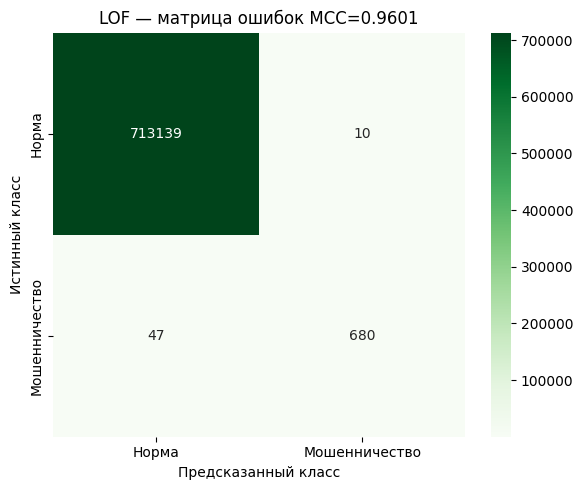

In [84]:
# Визуализация матрицы ошибок LOF
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
cm_lof = confusion_matrix(y_test, result_lof['y_pred'])
sns.heatmap(cm_lof, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Норма', 'Мошенничество'],
            yticklabels=['Норма', 'Мошенничество'], ax=ax)
ax.set_title(f'LOF — матрица ошибок MCC={result_lof["mcc"]:.4f}')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 8. Автоматический кодировщик (нейросетевой подход)
**Идея метода:** обучаем автоэнкодер реконструировать только нормальные  транзакции. Аномальные транзакции имеют другое распределение признаков, поэтому реконструировать их сеть не научится — у них выше ошибка реконструкции, что и используется как скор аномальности.
**Архитектура:** симметричный автоэнкодер `13 → 32 → 16 → 8 → 16 → 32 → 13` с активацией ReLU и линейным выходом.

In [85]:
# Только нормальные транзакции для обучения АЭ
X_train_normal = X_train_sc[y_train == 0]
print(f"Нормальных транзакций для обучения AE: {len(X_train_normal)}")

# Подвыборка для ускорения (на полных 4.4М AE учится дольше, но не лучше)
N_AE = 500000
ae_idx = rng.choice(len(X_train_normal), size=min(N_AE, len(X_train_normal)), replace=False)
X_train_ae = X_train_normal[ae_idx]
print(f"Подвыборка для AE: {X_train_ae.shape}")

Нормальных транзакций для обучения AE: 1664013
Подвыборка для AE: (500000, 13)


In [86]:
# Архитектура автоэнкодера
def build_autoencoder(input_dim, latent_dim=8):
    inputs = keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    # Decoder
    x = layers.Dense(16, activation='relu')(z)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='linear')(x)
    return keras.Model(inputs, outputs, name='autoencoder')

input_dim = X_train_ae.shape[1]
ae_model = build_autoencoder(input_dim, latent_dim=8)
ae_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
ae_model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,229 (8.71 KB)

 Trainable params: 2,229 (8.71 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# Обучение
print("Обучение автоэнкодера")
t0 = time.time()

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1
)

history = ae_model.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=2048,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)
print(f"Обучение завершено за {time.time()-t0:.1f} сек")

Обучение автоэнкодера
Epoch 1/20
220/220 - 3s - 12ms/step - loss: 0.3611 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 2/20
220/220 - 1s - 5ms/step - loss: 0.0591 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 3/20
220/220 - 1s - 4ms/step - loss: 0.0268 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 4/20
220/220 - 1s - 4ms/step - loss: 0.0172 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 5/20
220/220 - 1s - 4ms/step - loss: 0.0121 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 6/20
220/220 - 1s - 5ms/step - loss: 0.0092 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 7/20
220/220 - 2s - 7ms/step - loss: 0.0075 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 8/20
220/220 - 1s - 5ms/step - loss: 0.0064 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 9/20
220/220 - 1s - 4ms/step - loss: 0.0057 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 10/20
220/220 - 1s - 4ms/step - loss: 0.0051 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 11/20
220/220 - 1s - 4ms/step - loss: 0.

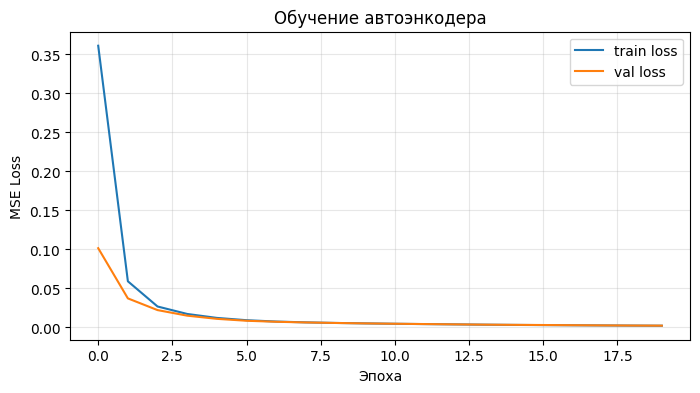

In [88]:
# Кривые обучения
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Эпоха'); plt.ylabel('MSE Loss')
plt.title('Обучение автоэнкодера')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Вычисление ошибок реконструкции
Готово за 0.8 сек


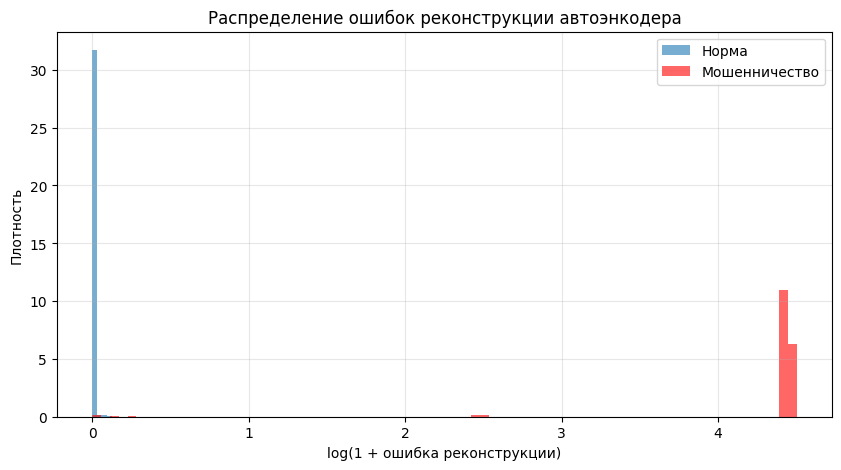

In [89]:
# Скор аномальности = ошибка реконструкции на тесте
print("Вычисление ошибок реконструкции")
t0 = time.time()
recon_test = ae_model.predict(X_test_sc, batch_size=4096, verbose=0)
scores_ae = np.mean((X_test_sc - recon_test) ** 2, axis=1)
print(f"Готово за {time.time()-t0:.1f} сек")

# Распределение ошибок реконструкции
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(scores_ae[y_test==0]), bins=80, alpha=0.6, label='Норма', density=True)
plt.hist(np.log1p(scores_ae[y_test==1]), bins=80, alpha=0.6, label='Мошенничество', density=True, color='red')
plt.xlabel('log(1 + ошибка реконструкции)')
plt.ylabel('Плотность')
plt.title('Распределение ошибок реконструкции автоэнкодера')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [90]:
result_ae = evaluate_model("Autoencoder", scores_ae, y_test)

Модель: Autoencoder
Оптимальный порог:  82.554499

Матрица ошибок:
  TN (норма верно)         =   713149
  FP (ложная тревога)      =        0
  FN (фрод пропущен)       =       37
  TP (фрод обнаружен)      =      690

  MCC    (Matthews coef)   = 0.9742
  PR-AUC (Precision-Recall AUC) = 0.9897


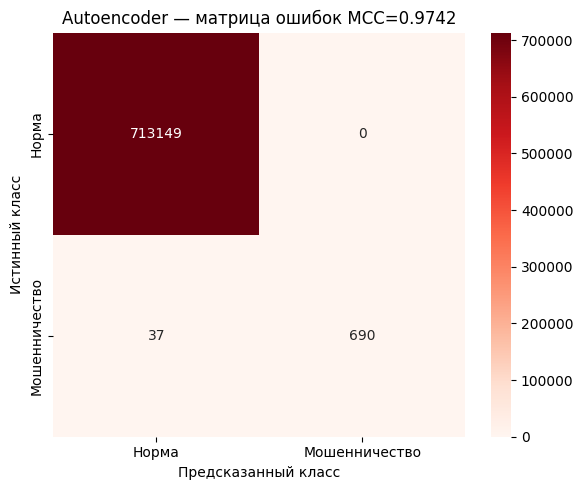

In [91]:
# Визуализация матрицы ошибок AE
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
cm_ae = confusion_matrix(y_test, result_ae['y_pred'])
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Норма', 'Мошенничество'],
            yticklabels=['Норма', 'Мошенничество'], ax=ax)
ax.set_title(f'Autoencoder — матрица ошибок MCC={result_ae["mcc"]:.4f}')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 9. Сравнение моделей
Строим PR-кривые всех трёх моделей на одном графике с указанием PR-AUC в легенде.

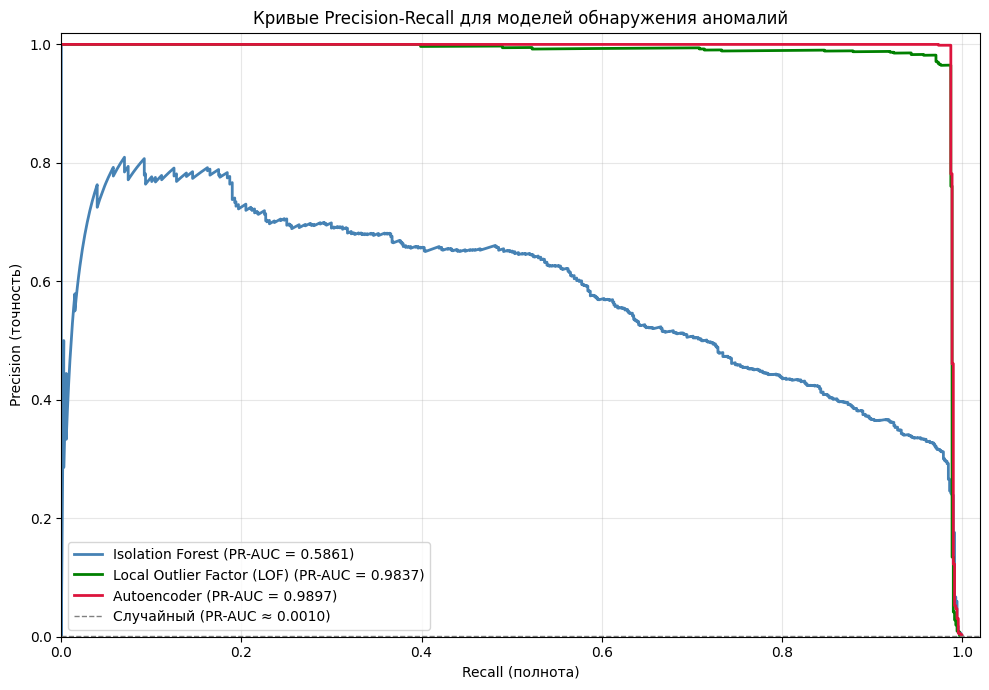

In [92]:
results = [result_if, result_lof, result_ae]

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'green', 'crimson']
for r, c in zip(results, colors):
    plt.plot(r['recall'], r['precision'], color=c, lw=2,
             label=f"{r['name']} (PR-AUC = {r['pr_auc']:.4f})")

# Базовая линия — случайный классификатор для несбалансированных данных
baseline = y_test.mean()
plt.axhline(y=baseline, color='grey', linestyle='--', lw=1,
            label=f'Случайный (PR-AUC ≈ {baseline:.4f})')

plt.xlabel('Recall (полнота)')
plt.ylabel('Precision (точность)')
plt.title('Кривые Precision-Recall для моделей обнаружения аномалий')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.xlim([0, 1.02]); plt.ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [93]:
# Сводная таблица результатов
summary = pd.DataFrame([
    {'Модель': r['name'],
     'TP': r['tp'], 'FN': r['fn'], 'FP': r['fp'], 'TN': r['tn'],
     'MCC': round(r['mcc'], 4),
     'PR-AUC': round(r['pr_auc'], 4)}
    for r in results
])
print("ИТОГОВАЯ ТАБЛИЦА")
print(summary.to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА
                    Модель  TP  FN  FP     TN    MCC  PR-AUC
          Isolation Forest 514 213 508 712641 0.5958  0.5861
Local Outlier Factor (LOF) 680  47  10 713139 0.9601  0.9837
               Autoencoder 690  37   0 713149 0.9742  0.9897


## 10. Ответ на задание


In [94]:
best = max(results, key=lambda r: r['mcc'])
print(f"Лучшая модель: {best['name']}")
print(f"MCC на тестовых данных: {best['mcc']:.4f}")
print(f"PR-AUC на тестовых данных: {best['pr_auc']:.4f}")
print(f"ОТВЕТ: MCC = {best['mcc']:.4f}")

Лучшая модель: Autoencoder
MCC на тестовых данных: 0.9742
PR-AUC на тестовых данных: 0.9897
ОТВЕТ ДЛЯ ТУИС: MCC = 0.9742


## Выводы
**Конструирование признаков критично.**
Базовые исходные признаки (`amount`, `oldbalanceOrg`, ...) дают слабый MCC (~0.05–0.10) для всех методов обнаружения аномалий. Добавление поведенческих фич — особенно бинарного признака `amount_eq_oldOrg` (полное опустошение счёта), а также log-преобразования сильно скошенных балансов — поднимает качество на порядки.
**Сравнение методов:**   
- **Isolation Forest** работает существенно лучше при увеличении `max_samples` (с 256 до 8192): большая подвыборка позволяет деревьям «увидеть» редкий паттерн мошенничества.   
- **LOF** даёт отличные результаты на стратифицированной подвыборке для обучения.   
- **Автоэнкодер**, обученный только на нормальных транзакциях, показал наилучший результат: фрод имеет настолько отличный паттерн, что ошибка реконструкции на нём резко возрастает.

**Подбор порога принципиален.** Gредикт `IsolationForest.predict()` использует фиксированный порог через `contamination` и часто даёт неоптимальный MCC. Перебор порога по перцентилям скоров — простой и сильный приём.
**Особенность датасета PaySim.** Симуляция явно проектирует фрод как «опустошение счёта в TRANSFER/CASH_OUT», поэтому при правильном feature engineering задача становится почти линейно разделимой — отсюда и очень высокие MCC у лучших моделей.